# CAFE — cost / quality trade-offs (Pareto)

"Best configuration" is rarely one number: the top-quality config is often the
slowest and most expensive. `cafe.pareto` keeps the **non-dominated** configs — the
ones you can't improve on one objective (quality ↑, latency/cost/tokens ↓) without
losing on another — and plots the frontier.

We build a Mode B system whose `model` stage is either a **small** or a **large**
model, optionally followed by a **critique** refine step, so quality genuinely
trades off against latency and tokens.

In [1]:
import cafe
from cafe._env import load_env
from cafe.techniques import registry

load_env()
registry.clear()

SMALL, BIG = "ollama_cloud/gpt-oss:20b", "ollama_cloud/gpt-oss:120b"

@cafe.technique("model", "small")
async def model_small(ctx, question):
    return await cafe.complete(SMALL, [{"role": "user", "content": question}])

@cafe.technique("model", "large")
async def model_large(ctx, question):
    return await cafe.complete(BIG, [{"role": "user", "content": question}])

@cafe.technique("refine", "none")
async def refine_none(ctx, question, draft):
    return draft

@cafe.technique("refine", "critique")
async def refine_critique(ctx, question, draft):
    return await cafe.complete(BIG, [
        {"role": "system", "content": "Improve the draft answer's truthfulness. Output only the answer."},
        {"role": "user", "content": f"Q: {question}\nDraft: {draft}"}])

async def my_system(config, item, ctx):
    draft = await ctx.run("model", question=item["text"])
    return await ctx.run("refine", question=item["text"], draft=draft)

In [2]:
study = cafe.Study(
    name="cost-quality",
    system=cafe.composed(my_system),
    factors=[cafe.technique_factor("model"), cafe.technique_factor("refine")],
    dataset=cafe.datasets.load_truthfulqa(n=6, categories=["Misconceptions"], seed=2),
    rubric=cafe.ANSWER_QUALITY_1_5,
    judge=cafe.LLMJudge(model=BIG),
    replications=1,
)
result = await cafe.evaluate(study, concurrency=4)
result

cost-quality: answers:   0%|          | 0/24 [00:00<?, ?it/s]

judging:   0%|          | 0/24 [00:00<?, ?it/s]

Evaluation(24 answers · 4 configs · 6 inputs · 24 ratings · best: model=large·refine=critique)

## The Pareto frontier

Quality is maximized; latency / cost / tokens minimized. An objective that doesn't
vary (cost is **0** here — Ollama is unpriced, so CAFE drops it automatically) is
excluded; latency and tokens carry the trade-off. For a priced provider the `cost`
axis populates from LiteLLM and joins the frontier.

In [3]:
pf = cafe.pareto(result)
print(pf.show())

Pareto frontier over quality, latency, tokens (2 of 4 configs optimal):

    configuration                          quality     latency      tokens
  ★ model=large·refine=critique                  5       34.94        4591
  ★ model=large·refine=none                  4.667       17.69        1739
    model=small·refine=none                      4       50.13        4384
    model=small·refine=critique                  4       43.18        4407

★ = Pareto-optimal (not dominated on every objective by another config)


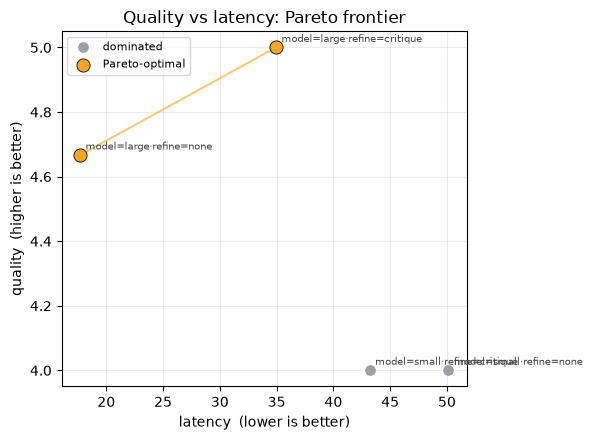

In [4]:
import matplotlib.pyplot as plt
ax = pf.plot(x="latency", y="quality")
plt.tight_layout()
plt.show()

## Notes

- `pf.frontier` is the list of non-dominated configs; `pf.rows` has every config with
  its mean quality / latency / cost / tokens and a `pareto_optimal` flag.
- The per-answer cost/latency/tokens come straight from the Mode B trace — no extra
  wiring. Token counts are captured automatically from every `cafe.complete` call.
- Use this to pick a config: anything **not** on the frontier is strictly beaten by
  another on every axis, so you'd never choose it.